In [1]:
from sklearn.datasets import load_diabetes
import pandas as pd


diabetes = load_diabetes()

df = pd.DataFrame(data=diabetes.data, columns=diabetes.feature_names)
df['target'] = diabetes.target

print("Dataset loaded successfully. Here are the first 5 rows:")
display(df.head())

Dataset loaded successfully. Here are the first 5 rows:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [2]:

print("DataFrame Info:")
df.info()

print("\nChecking for missing values:")
display(df.isnull().sum())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB

Checking for missing values:


,0
age,0
sex,0
bmi,0
bp,0
s1,0
s2,0
s3,0
s4,0
s5,0
s6,0


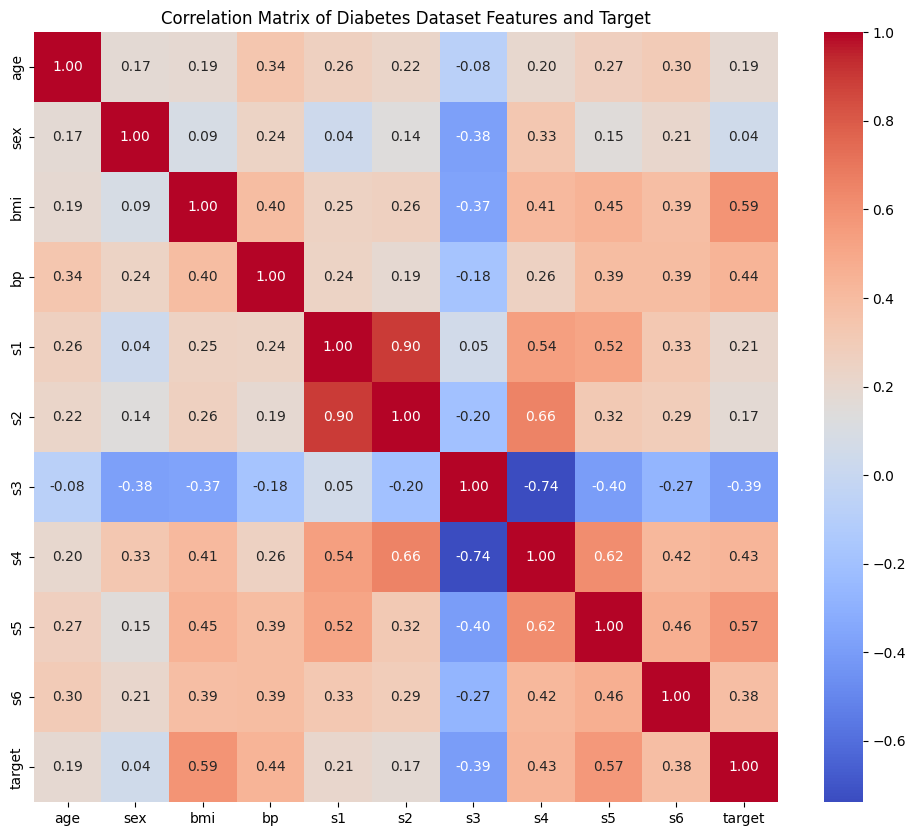


Correlation with Target Variable:


,target
target,1.000000
bmi,0.586450
s5,0.565883
bp,0.441482
s4,0.430453
s6,0.382483
s1,0.212022
age,0.187889
s2,0.174054
sex,0.043062


In [6]:
import seaborn as sns
import matplotlib.pyplot as plt


correlation_matrix = df.corr()


plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Diabetes Dataset Features and Target')
plt.show()


print("\nCorrelation with Target Variable:")
display(correlation_matrix['target'].sort_values(ascending=False))

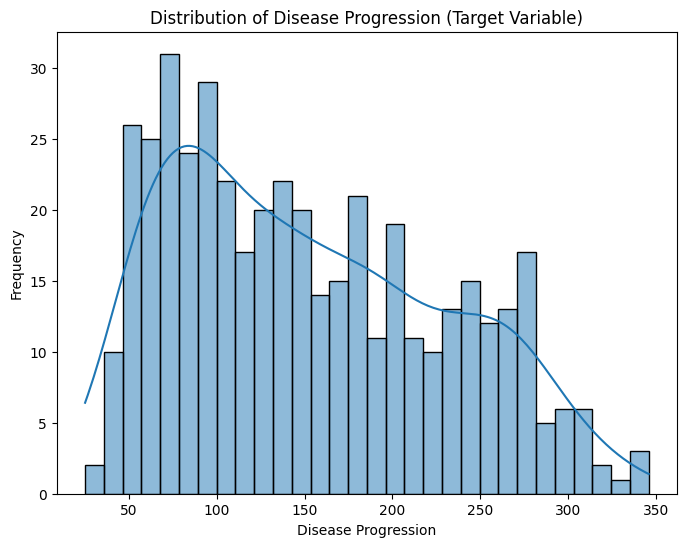

In [7]:

plt.figure(figsize=(8, 6))
sns.histplot(df['target'], kde=True, bins=30)
plt.title('Distribution of Disease Progression (Target Variable)')
plt.xlabel('Disease Progression')
plt.ylabel('Frequency')
plt.show()

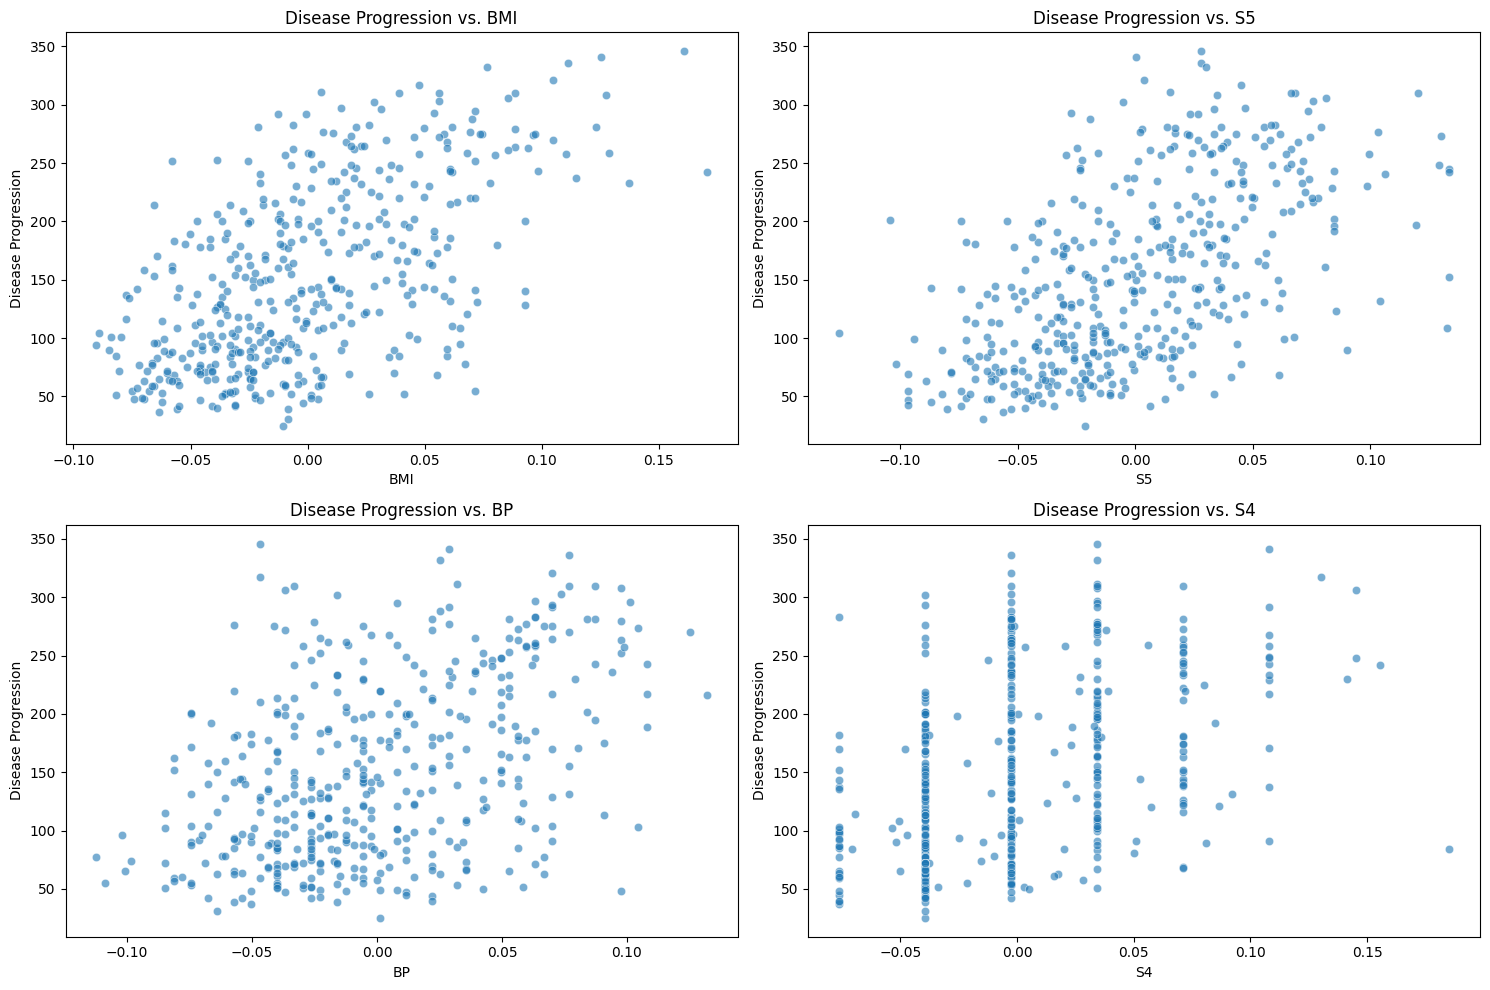

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns


top_correlated_features = correlation_matrix['target'].drop('target').sort_values(ascending=False).index.tolist()

# Select the top 4 for visualization
features_to_plot = top_correlated_features[:4]

plt.figure(figsize=(15, 10))

for i, feature in enumerate(features_to_plot):
    plt.subplot(2, 2, i + 1) # Create a 2x2 grid of plots
    sns.scatterplot(x=df[feature], y=df['target'], alpha=0.6)
    plt.title(f'Disease Progression vs. {feature.upper()}')
    plt.xlabel(feature.upper())
    plt.ylabel('Disease Progression')

plt.tight_layout()
plt.show()